# Customer Churn — Data Preprocessing Pipeline
**Role:** Data Engineer / Preprocessing Specialist  
**Purpose:** Build and validate the sklearn preprocessing pipeline.

In [ ]:
import sys, os
sys.path.append('..')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from src.feature_engineering import (
    DateFeatureExtractor, DropColumnsTransformer,
    ServiceBundleFeatures, FinancialRatioFeatures,
    CATEGORICAL_COLS, NUMERICAL_COLS, DROP_COLS, TARGET_COL,
)
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'C:\Users\OVER CLOCK\Downloads\customer_churn_project\customer_churn_project\data\raw\customer_churn.csv', nrows=50_000)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

## 1. Missing Value Analysis

                       Missing Count  Missing %
avg_monthly_gb                  2557       5.11
credit_score                    2088       4.18
num_complaints                  1530       3.06
annual_income                   1476       2.95
customer_satisfaction           1000       2.00


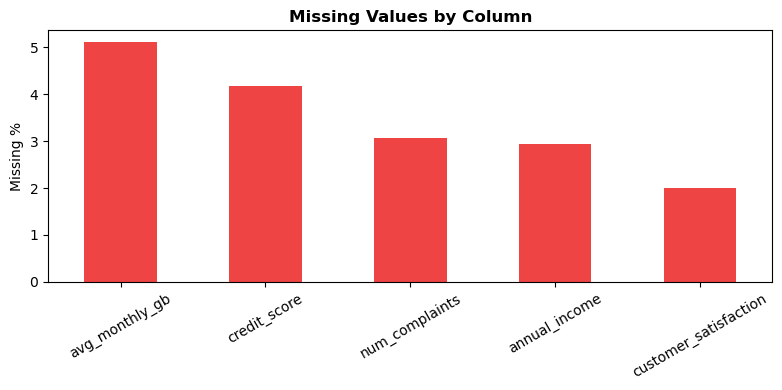

In [ ]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv = mv[mv['Missing Count'] > 0]
print(mv)

fig, ax = plt.subplots(figsize=(8, 4))
mv['Missing %'].plot(kind='bar', ax=ax, color='#EF4444')
ax.set_title('Missing Values by Column', fontweight='bold')
ax.set_ylabel('Missing %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/preprocessing_missing_values.png', dpi=150)
plt.show()

## 2. Duplicate Detection

In [ ]:
dupe_rows = df_raw.duplicated().sum()
dupe_ids  = df_raw['customer_id'].duplicated().sum()
print(f'Duplicate rows: {dupe_rows}')
print(f'Duplicate customer_ids: {dupe_ids}')

# Drop if any exist
df_clean = df_raw.drop_duplicates(subset='customer_id').copy()
print(f'Shape after dedup: {df_clean.shape}')

Duplicate rows: 0
Duplicate customer_ids: 0
Shape after dedup: (50000, 32)


## 3. Outlier Detection

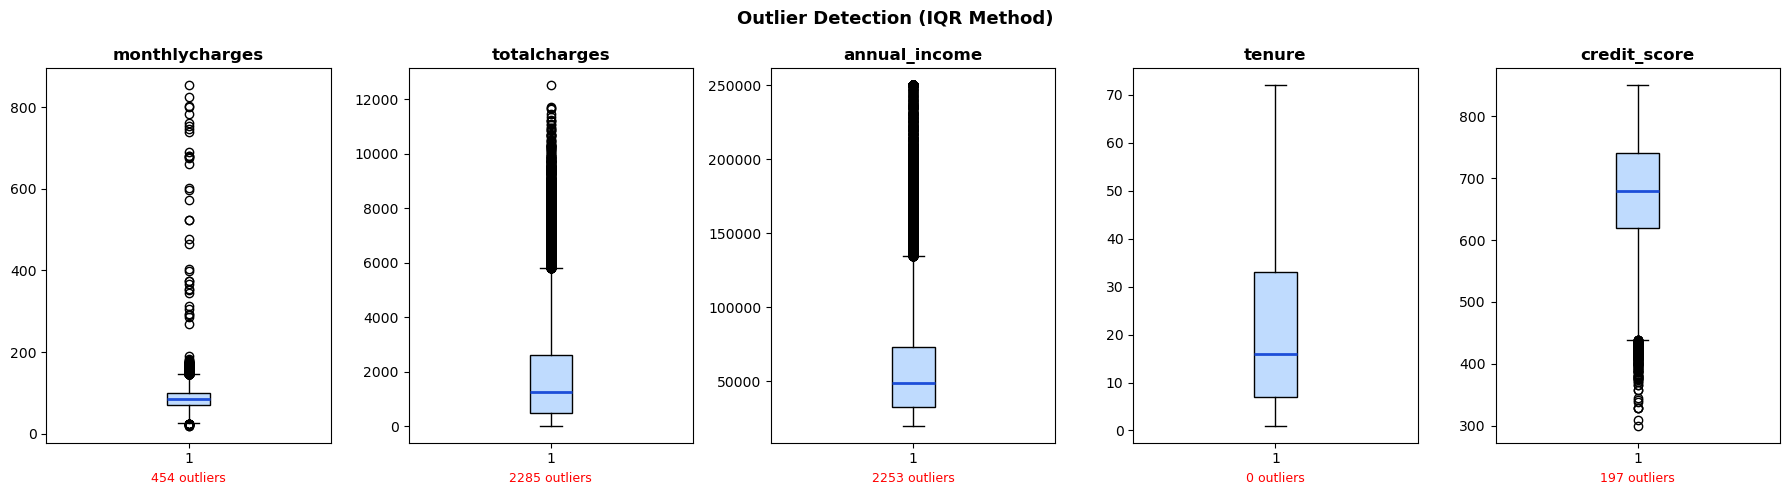

In [ ]:
outlier_cols = ['monthlycharges', 'totalcharges', 'annual_income', 'tenure', 'credit_score']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    data = df_clean[col].dropna()
    axes[i].boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='#BFDBFE'),
                    medianprops=dict(color='#1D4ED8', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'{outliers} outliers', color='red', fontsize=9)

plt.suptitle('Outlier Detection (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/preprocessing_outliers.png', dpi=150)
plt.show()

## 4. Build & Validate the Preprocessing Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

extra_num = [
    'signup_year', 'signup_month',
    'total_services_subscribed', 'service_penetration_rate',
    'charges_per_service', 'income_to_charge_ratio', 'late_payment_rate',
]
num_cols = [c for c in NUMERICAL_COLS if c != TARGET_COL] + extra_num
cat_cols = CATEGORICAL_COLS

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols),
], remainder='drop')

full_preprocessing = Pipeline([
    ('date_features',      DateFeatureExtractor()),
    ('service_features',   ServiceBundleFeatures()),
    ('financial_features', FinancialRatioFeatures()),
    ('drop_cols',          DropColumnsTransformer(DROP_COLS)),
    ('preprocessor',       preprocessor),
])

X_transformed = full_preprocessing.fit_transform(X_train, y_train)
print(f'Input shape:  {X_train.shape}')
print(f'Output shape: {X_transformed.shape}')
print('Pipeline validated ✓')

Input shape:  (40000, 31)
Output shape: (40000, 51)
Pipeline validated ✓


## 5. Post-Processing Verification

Any NaN after pipeline: False
Feature matrix shape: (40000, 51)
Value range: [-4.41, 38.34]


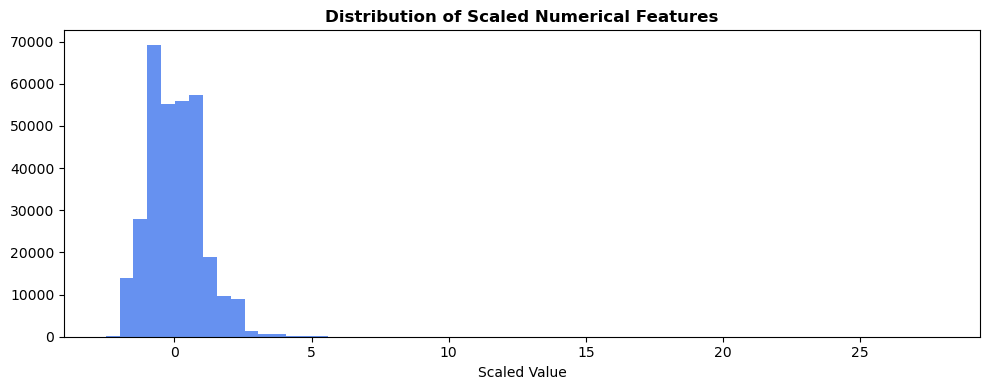

In [ ]:
import pandas as pd
X_out = pd.DataFrame(X_transformed)
print(f'Any NaN after pipeline: {X_out.isnull().any().any()}')
print(f'Feature matrix shape: {X_out.shape}')
print(f'Value range: [{X_out.values.min():.2f}, {X_out.values.max():.2f}]')

# Visualize scaled numerical distributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X_out.iloc[:, :8].values.flatten(), bins=60, color='#2563EB', alpha=0.7)
ax.set_title('Distribution of Scaled Numerical Features', fontweight='bold')
ax.set_xlabel('Scaled Value')
plt.tight_layout()
plt.savefig('../reports/preprocessing_scaled_features.png', dpi=150)
plt.show()